In [3]:
import pandas as pd

df = pd.read_csv('train_road_safety.csv')

df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46649 entries, 0 to 46648
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   status                              44293 non-null  object 
 1   collision_index                     46649 non-null  object 
 2   collision_year                      44261 non-null  float64
 3   collision_reference                 44343 non-null  object 
 4   vehicle_reference                   46649 non-null  float64
 5   casualty_reference                  46649 non-null  float64
 6   casualty_class                      46649 non-null  int64  
 7   sex_of_casualty                     44319 non-null  float64
 8   age_of_casualty                     46649 non-null  int64  
 9   age_band_of_casualty                46649 non-null  int64  
 10  pedestrian_location                 46649 non-null  float64
 11  pedestrian_movement                 46649

,collision_year,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,enhanced_casualty_severity,casualty_severity
count,44261.0,46649.000000,46649.000000,46649.000000,44319.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,44314.000000,46649.000000,44292.000000,46649.000000,46649.000000,46649.000000
mean,2024.0,1.455616,1.353898,1.485520,1.366637,37.102982,6.326502,0.795227,0.657442,0.196574,0.058072,0.031548,9.314112,0.993227,4.132307,1.582220,2.882741
std,0.0,1.444068,1.267332,0.732898,0.577406,19.826586,2.493991,2.196648,2.047634,0.647400,0.465305,0.286917,15.842578,0.979042,3.286280,2.273239,0.362108
min,2024.0,0.462251,0.595506,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,2024.0,1.000000,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,-1.000000,3.000000
50%,2024.0,1.000000,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,4.000000,3.000000,3.000000
75%,2024.0,2.000000,1.000000,2.000000,2.000000,51.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,7.000000,3.000000,3.000000
max,2024.0,203.000000,202.000000,3.000000,9.000000,120.000000,11.000000,10.334651,9.000000,9.000000,9.000000,2.000000,98.000000,3.000000,10.000000,7.000000,3.000000


In [4]:
import numpy as np

df.drop(columns=["status", "collision_year", "collision_reference","lsoa_of_casualty","age_band_of_casualty","collision_index","enhanced_casualty_severity"], inplace=True)


In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=["casualty_severity"])
y = df["casualty_severity"] - 1  # klasifikasi 0, 1, 2

label_encoders = {}
for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, VotingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier

models = [
    ("LogisticRegression", LogisticRegression(max_iter=1000, random_state=42)),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("GaussianNB", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(random_state=42)),
    ("ExtraTrees", ExtraTreesClassifier(random_state=42)),
    ("Bagging", BaggingClassifier(random_state=42)),
    ("AdaBoost", AdaBoostClassifier(random_state=42)),
    ("GradientBoost", GradientBoostingClassifier(random_state=42)),
    ("HistGradientBoost", HistGradientBoostingClassifier(random_state=42)),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis())
]

# Tambahkan Voting Classifier
voting = VotingClassifier(estimators=[
    ("xgb", XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)),
    ("gb", GradientBoostingClassifier(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
], voting="soft")
models.append(("Voting", voting))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models:
    try:
        scores = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=cv, n_jobs=-1)
        results.append((name, scores.mean(), scores.std()))
    except Exception as e:
        print(f"{name} error: {e}")

results_df = pd.DataFrame(results, columns=["Algorithm", "CrossValMeans", "CrossValStd"])
results_df = results_df.sort_values(by="CrossValMeans", ascending=False).reset_index(drop=True)

print("Fitur yang digunakan:")
print(X.columns.tolist())
print(results_df)


LogisticRegression error: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1222, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py", line 2961, in validate_data
    X, y = check_X_y

In [6]:
!pip install optuna
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === HistGradientBoost ===
def objective_hgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_iter": trial.suggest_int("max_iter", 100, 300),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 10, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 50),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 10.0)
    }
    model = HistGradientBoostingClassifier(random_state=42, **params)
    return cross_val_score(model, X_train, y_train, scoring='accuracy', cv=kfold).mean()

study_hgb = optuna.create_study(direction="maximize")
study_hgb.optimize(objective_hgb, n_trials=30)

# === XGBoost ===
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }
    model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', **params)
    return cross_val_score(model, X_train, y_train, scoring='accuracy', cv=kfold).mean()

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=30)

# === Random Forest ===
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 5, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10)
    }
    model = RandomForestClassifier(random_state=42, **params)
    return cross_val_score(model, X_train, y_train, scoring='accuracy', cv=kfold).mean()

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=30)

# === Print Best Results ===
print("=== Best HistGradientBoost Parameters ===")
print(study_hgb.best_params)
print("Best Accuracy:", study_hgb.best_value)

print("\n=== Best XGBoost Parameters ===")
print(study_xgb.best_params)
print("Best Accuracy:", study_xgb.best_value)

print("\n=== Best Random Forest Parameters ===")
print(study_rf.best_params)
print("Best Accuracy:", study_rf.best_value)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 18.8 MB/s eta 0:00:00


[I 2025-06-25 14:03:44,399] A new study created in memory with name: no-name-a8490a9e-5b8a-4ee3-8c82-89ee7fc7cc22
[I 2025-06-25 14:03:46,866] Trial 0 finished with value: 0.8963530731602092 and parameters: {'learning_rate': 0.253602154406092, 'max_iter': 186, 'max_leaf_nodes': 30, 'min_samples_leaf': 41, 'l2_regularization': 2.5052797906925717}. Best is trial 0 with value: 0.8963530731602092.
[I 2025-06-25 14:03:49,344] Trial 1 finished with value: 0.8964602542963291 and parameters: {'learning_rate': 0.2483836917291716, 'max_iter': 252, 'max_leaf_nodes': 36, 'min_samples_leaf': 17, 'l2_regularization': 3.5447075702373763}. Best is trial 1 with value: 0.8964602542963291.
[I 2025-06-25 14:03:56,537] Trial 2 finished with value: 0.8964870459899419 and parameters: {'learning_rate': 0.04201124371829881, 'max_iter': 103, 'max_leaf_nodes': 22, 'min_samples_leaf': 24, 'l2_regularization': 1.0736059490105565}. Best is trial 2 with value: 0.8964870459899419.
[I 2025-06-25 14:03:58,550] Trial 3 f

=== Best HistGradientBoost Parameters ===
{'learning_rate': 0.14998385129355019, 'max_iter': 232, 'max_leaf_nodes': 27, 'min_samples_leaf': 38, 'l2_regularization': 4.300091701628642}
Best Accuracy: 0.8965406401484193

=== Best XGBoost Parameters ===
{'n_estimators': 295, 'learning_rate': 0.015381730189364536, 'max_depth': 4, 'subsample': 0.6602838200059551, 'colsample_bytree': 0.8373773021287592}
Best Accuracy: 0.896540636558002

=== Best Random Forest Parameters ===
{'n_estimators': 168, 'max_depth': 11, 'max_features': 'log2', 'min_samples_split': 9}
Best Accuracy: 0.8965674354324493


=== HistGradientBoost (Skenario 1.2) ===
Accuracy: 0.8965702036441586
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       129
           1       0.00      0.00      0.00       836
           2       0.90      1.00      0.95      8365

    accuracy                           0.90      9330
   macro avg       0.30      0.33      0.32      9330
weighted avg       0.80      0.90      0.85      9330



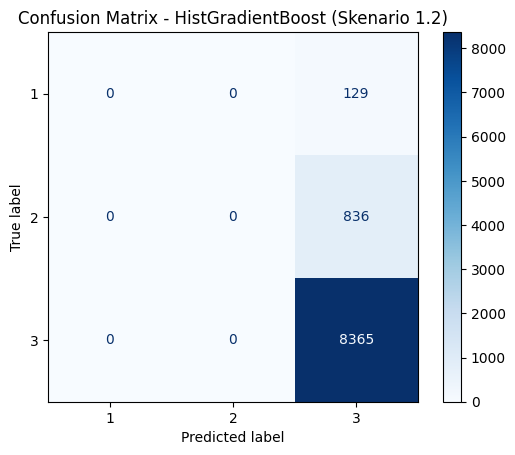


=== XGBoost (Skenario 1.2) ===
Accuracy: 0.8965702036441586
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       129
           1       0.00      0.00      0.00       836
           2       0.90      1.00      0.95      8365

    accuracy                           0.90      9330
   macro avg       0.30      0.33      0.32      9330
weighted avg       0.80      0.90      0.85      9330



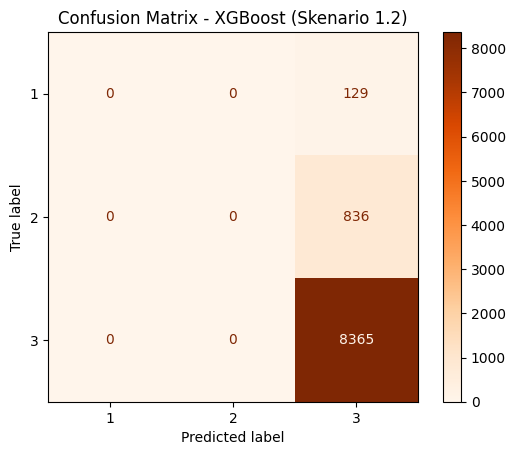


=== Random Forest (Skenario 1.2) ===
Accuracy: 0.8965702036441586
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       129
           1       0.00      0.00      0.00       836
           2       0.90      1.00      0.95      8365

    accuracy                           0.90      9330
   macro avg       0.30      0.33      0.32      9330
weighted avg       0.80      0.90      0.85      9330



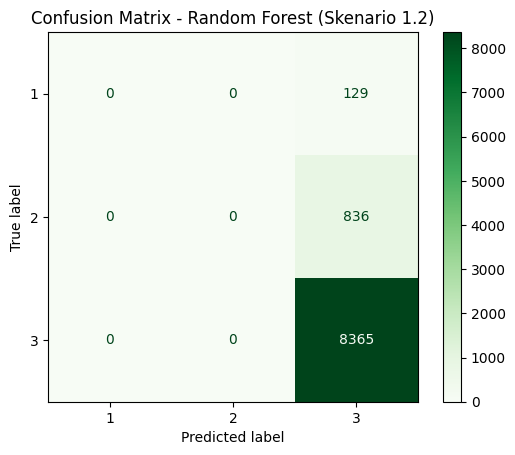

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# === 1. HistGradientBoost ===
hgb_best_12 = HistGradientBoostingClassifier(
    learning_rate=0.14998385129355019,
    max_iter=232,
    max_leaf_nodes=27,
    min_samples_leaf=38,
    l2_regularization=4.300091701628642,
    random_state=42
)
hgb_best_12.fit(X_train, y_train)
y_pred_hgb_12 = hgb_best_12.predict(X_test)

print("=== HistGradientBoost (Skenario 1.2) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_hgb_12))
print(classification_report(y_test, y_pred_hgb_12))

cm_hgb_12 = confusion_matrix(y_test, y_pred_hgb_12)
ConfusionMatrixDisplay(confusion_matrix=cm_hgb_12, display_labels=[1, 2, 3]).plot(cmap='Blues')
plt.title("Confusion Matrix - HistGradientBoost (Skenario 1.2)")
plt.show()

# === 2. XGBoost ===
xgb_best_12 = XGBClassifier(
    n_estimators=295,
    learning_rate=0.015381730189364536,
    max_depth=4,
    subsample=0.6602838200059551,
    colsample_bytree=0.8373773021287592,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_best_12.fit(X_train, y_train)
y_pred_xgb_12 = xgb_best_12.predict(X_test)

print("\n=== XGBoost (Skenario 1.2) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_12))
print(classification_report(y_test, y_pred_xgb_12))

cm_xgb_12 = confusion_matrix(y_test, y_pred_xgb_12)
ConfusionMatrixDisplay(confusion_matrix=cm_xgb_12, display_labels=[1, 2, 3]).plot(cmap='Oranges')
plt.title("Confusion Matrix - XGBoost (Skenario 1.2)")
plt.show()

# === 3. Random Forest ===
rf_best_12 = RandomForestClassifier(
    n_estimators=168,
    max_depth=11,
    max_features='log2',
    min_samples_split=9,
    random_state=42
)
rf_best_12.fit(X_train, y_train)
y_pred_rf_12 = rf_best_12.predict(X_test)

print("\n=== Random Forest (Skenario 1.2) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_12))
print(classification_report(y_test, y_pred_rf_12))

cm_rf_12 = confusion_matrix(y_test, y_pred_rf_12)
ConfusionMatrixDisplay(confusion_matrix=cm_rf_12, display_labels=[1, 2, 3]).plot(cmap='Greens')
plt.title("Confusion Matrix - Random Forest (Skenario 1.2)")
plt.show()
